# Exploratory Data Analysis
### Demystifying Credit Risk: An XAI Framework for Loan Default Prediction in Inclusive Lending

- **Stage B** — the accepted-loan population (default prediction). Runs against
  real data unconditionally (Kaggle if configured, a real public fallback
  mirror otherwise).
- **Stage A** — the combined accepted + rejected population (acceptance
  prediction). Requires the real Kaggle `rejected_2007_to_2018Q4.csv`; cells
  are structured to run identically once that file is available, and print a
  clear message instead of fabricating output if it is not.

Every chart here is also saved to `outputs/figures/` by `run_pipeline.py`, so
this notebook and the pipeline script always agree with each other.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, data_loader, preprocessing, feature_engineering

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
np.random.seed(config.SEED)

## Part 1 — Stage B: Accepted-Loan Data (Default Prediction)

### 1.1 Shape and data types

In [2]:
accepted_raw = data_loader.load_accepted_data()
print("Shape:", accepted_raw.shape)
accepted_raw.dtypes

2026-09-13 09:34:54,283 [INFO] Loading local accepted-loan data from C:\Users\user\Documents\Research\Actual MSc Thesis\Full Update September Project\LOAN_XAI\data\accepted_2007_to_2018Q4.csv


Shape: (2260701, 151)


id                        object
member_id                float64
loan_amnt                float64
funded_amnt              float64
funded_amnt_inv          float64
                          ...   
settlement_status         object
settlement_date           object
settlement_amount        float64
settlement_percentage    float64
settlement_term          float64
Length: 151, dtype: object

### 1.2 Summary statistics

In [3]:
accepted_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2260701,2260701,Total amount funded in policy code 2: 521953170,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,NaN,NaN,NaN,15046.931228,9190.245488,500.0,8000.0,12900.0,20000.0,40000.0
funded_amnt,2260668.0,NaN,NaN,NaN,15041.664057,9188.413022,500.0,8000.0,12875.0,20000.0,40000.0
funded_amnt_inv,2260668.0,NaN,NaN,NaN,15023.437745,9192.331679,0.0,8000.0,12800.0,20000.0,40000.0
...,...,...,...,...,...,...,...,...,...,...,...
settlement_status,34246,3,ACTIVE,14704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
settlement_date,34246,90,Jan-2019,1710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
settlement_amount,34246.0,NaN,NaN,NaN,5010.664267,3693.12259,44.21,2208.0,4146.11,6850.1725,33601.0
settlement_percentage,34246.0,NaN,NaN,NaN,47.780365,7.311822,0.2,45.0,45.0,50.0,521.35


### 1.3 Missing values

In [4]:
missing = accepted_raw.isna().sum()
missing_pct = (missing / len(accepted_raw) * 100).round(3)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table[missing_table["missing_count"] > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_pct
member_id,2260701,100.000
orig_projected_additional_accrued_interest,2252050,99.617
hardship_payoff_balance_amount,2249784,99.517
hardship_last_payment_amount,2249784,99.517
payment_plan_start_date,2249784,99.517
...,...,...
total_rec_int,33,0.001
total_rec_prncp,33,0.001
hardship_flag,33,0.001
disbursement_method,33,0.001


### 1.4 Target balance (`is_default`)

In [5]:
sorted(accepted_raw.columns)

['acc_now_delinq',
 'acc_open_past_24mths',
 'addr_state',
 'all_util',
 'annual_inc',
 'annual_inc_joint',
 'application_type',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'collection_recovery_fee',
 'collections_12_mths_ex_med',
 'debt_settlement_flag',
 'debt_settlement_flag_date',
 'deferral_term',
 'delinq_2yrs',
 'delinq_amnt',
 'desc',
 'disbursement_method',
 'dti',
 'dti_joint',
 'earliest_cr_line',
 'emp_length',
 'emp_title',
 'fico_range_high',
 'fico_range_low',
 'funded_amnt',
 'funded_amnt_inv',
 'grade',
 'hardship_amount',
 'hardship_dpd',
 'hardship_end_date',
 'hardship_flag',
 'hardship_last_payment_amount',
 'hardship_length',
 'hardship_loan_status',
 'hardship_payoff_balance_amount',
 'hardship_reason',
 'hardship_start_date',
 'hardship_status',
 'hardship_type',
 'home_ownership',
 'id',
 'il_util',
 'initial_list_status',
 'inq_fi',
 'inq_last_12m',
 'inq_last_6mths',
 'installment',
 'int_rate',
 'issue_d',
 'last_credit_pull_

In [6]:
# ---------------------------------------------------------------------------
# Stage B: Target definitions according to rigid thesis risk specifications
# ---------------------------------------------------------------------------

# 1. Define lists of explicitly acceptable vs. non-performing states
good_statuses = [
    "Fully Paid", 
    "Does not meet the credit policy. Status:Fully Paid"
]

bad_statuses = [
    "Charged Off", 
    "Late (31-120 days)", 
    "Does not meet the credit policy. Status:Charged Off", 
    "Default"
]

# 2. Drop transitory / ongoing profiles (Current, In Grace Period, Late 16-30)
# This eliminates indeterminate states whose final credit outcome is unknown
allowed_statuses = good_statuses + bad_statuses
accepted_filtered = accepted_raw[accepted_raw["loan_status"].isin(allowed_statuses)].copy()

# 3. Create the clean binary mapping dictionary
binary_map = {}
for status in good_statuses:
    binary_map[status] = 0
for status in bad_statuses:
    binary_map[status] = 1

# 4. Formally map to your synchronized thesis target variable 'is_default'
accepted_filtered["is_default"] = accepted_filtered["loan_status"].map(binary_map)

# 5. Drop the old unmapped column reference if it exists to clean the layout
if "target" in accepted_filtered.columns:
    accepted_filtered = accepted_filtered.drop(columns=["target"])

# Verify the final clean structural mapping split
print("Final Target Class Imbalance Split:")
print(accepted_filtered["is_default"].value_counts(normalize=True).round(4))

Final Target Class Imbalance Split:
is_default
0    0.7877
1    0.2123
Name: proportion, dtype: float64


2026-09-13 13:32:57,506 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


loan_status
Fully Paid                                             0.7862
Charged Off                                            0.1961
Late (31-120 days)                                     0.0157
Does not meet the credit policy. Status:Fully Paid     0.0015
Does not meet the credit policy. Status:Charged Off    0.0006
Default                                                0.0000
Name: proportion, dtype: float64
is_default
0    0.7877
1    0.2123
Name: proportion, dtype: float64


2026-09-13 13:32:57,531 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


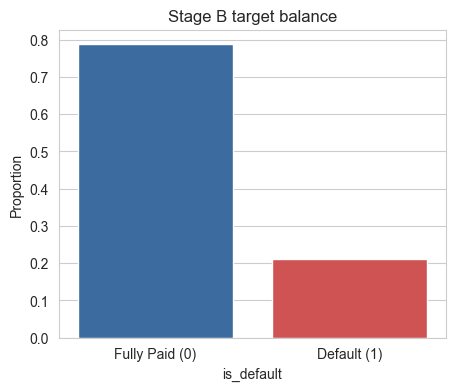

In [8]:
accepted_raw = accepted_filtered

target_balance = accepted_raw["is_default"].value_counts(normalize=True).round(4)
myloan_status = accepted_raw["loan_status"].value_counts(normalize=True).round(4)
print(myloan_status)
print(target_balance)

plt.figure(figsize=(5, 4))
sns.barplot(x=target_balance.index.astype(str), y=target_balance.values, palette=["#2b6cb0", "#e53e3e"])
plt.xticks([0, 1], ["Fully Paid (0)", "Default (1)"])
plt.ylabel("Proportion")
plt.title("Stage B target balance")
plt.show()

### 1.5 Duplicate check

In [9]:
print("Duplicate rows:", accepted_raw.duplicated().sum())

Duplicate rows: 0


In [10]:
print(accepted_raw.shape)

(1369566, 152)


### 1.6 Distributions of key numeric features

In [11]:
accepted_raw["issue_d_dt"] = pd.to_datetime(accepted_raw["issue_d"], format='%b-%Y', errors='coerce')
accepted_raw["earliest_cr_line_dt"] = pd.to_datetime(accepted_raw["earliest_cr_line"], format='%b-%Y', errors='coerce')

accepted_raw["longest_credit_length"] = (accepted_raw["issue_d_dt"] - accepted_raw["earliest_cr_line_dt"]).dt.days/365.25

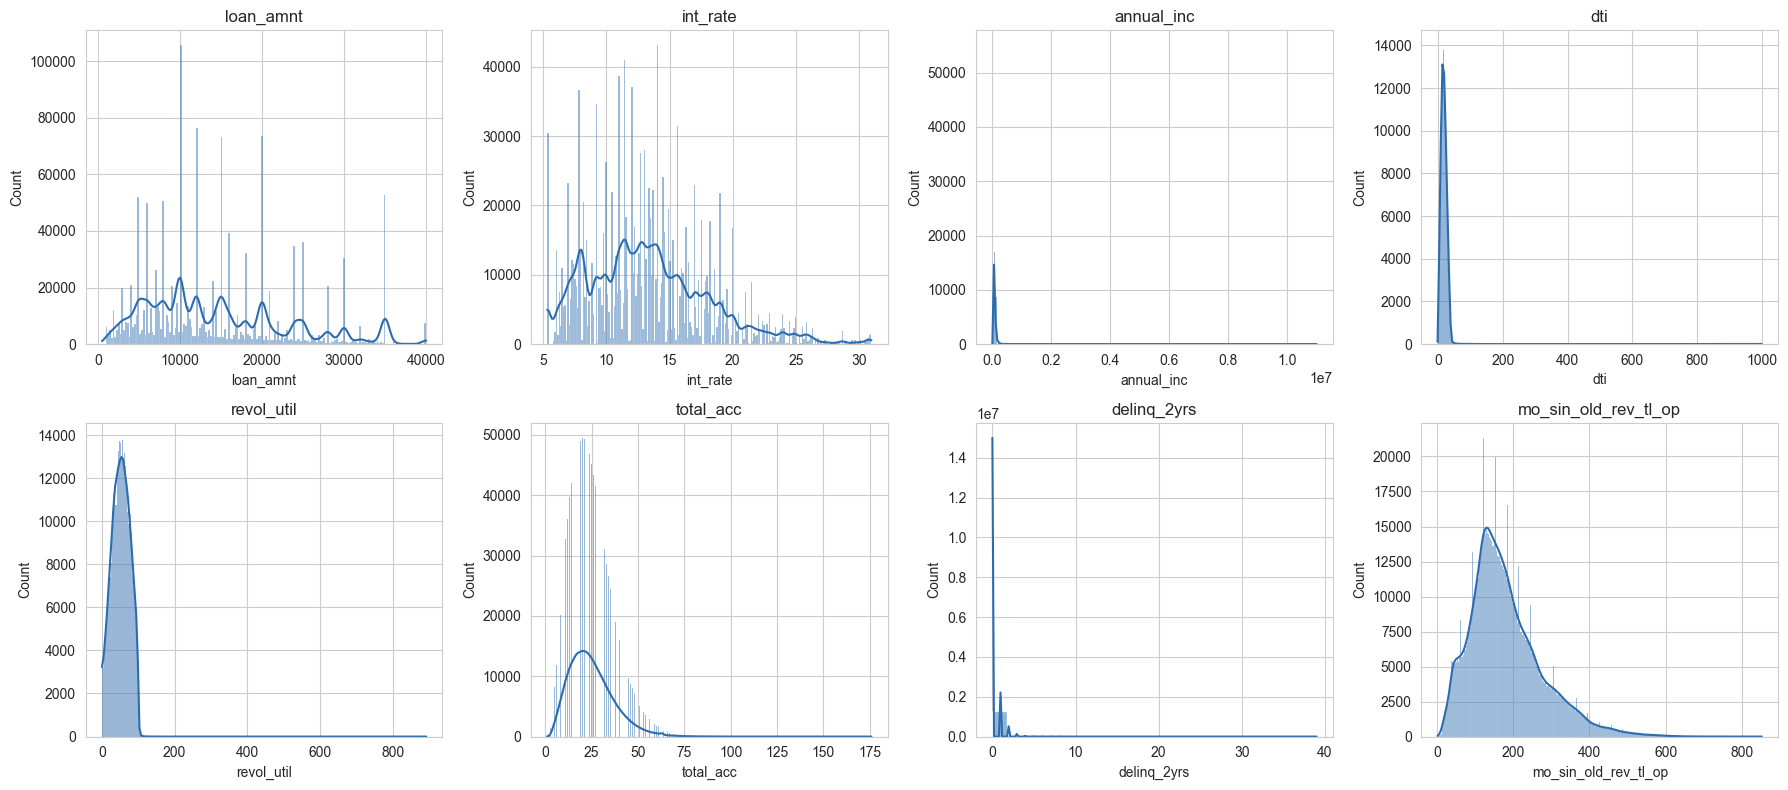

In [12]:
numeric_cols = ["loan_amnt", "int_rate", "annual_inc", "dti", "revol_util",
                "total_acc", "delinq_2yrs", "mo_sin_old_rev_tl_op"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(accepted_raw[col].dropna(), kde=True, ax=ax, color="#2b6cb0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

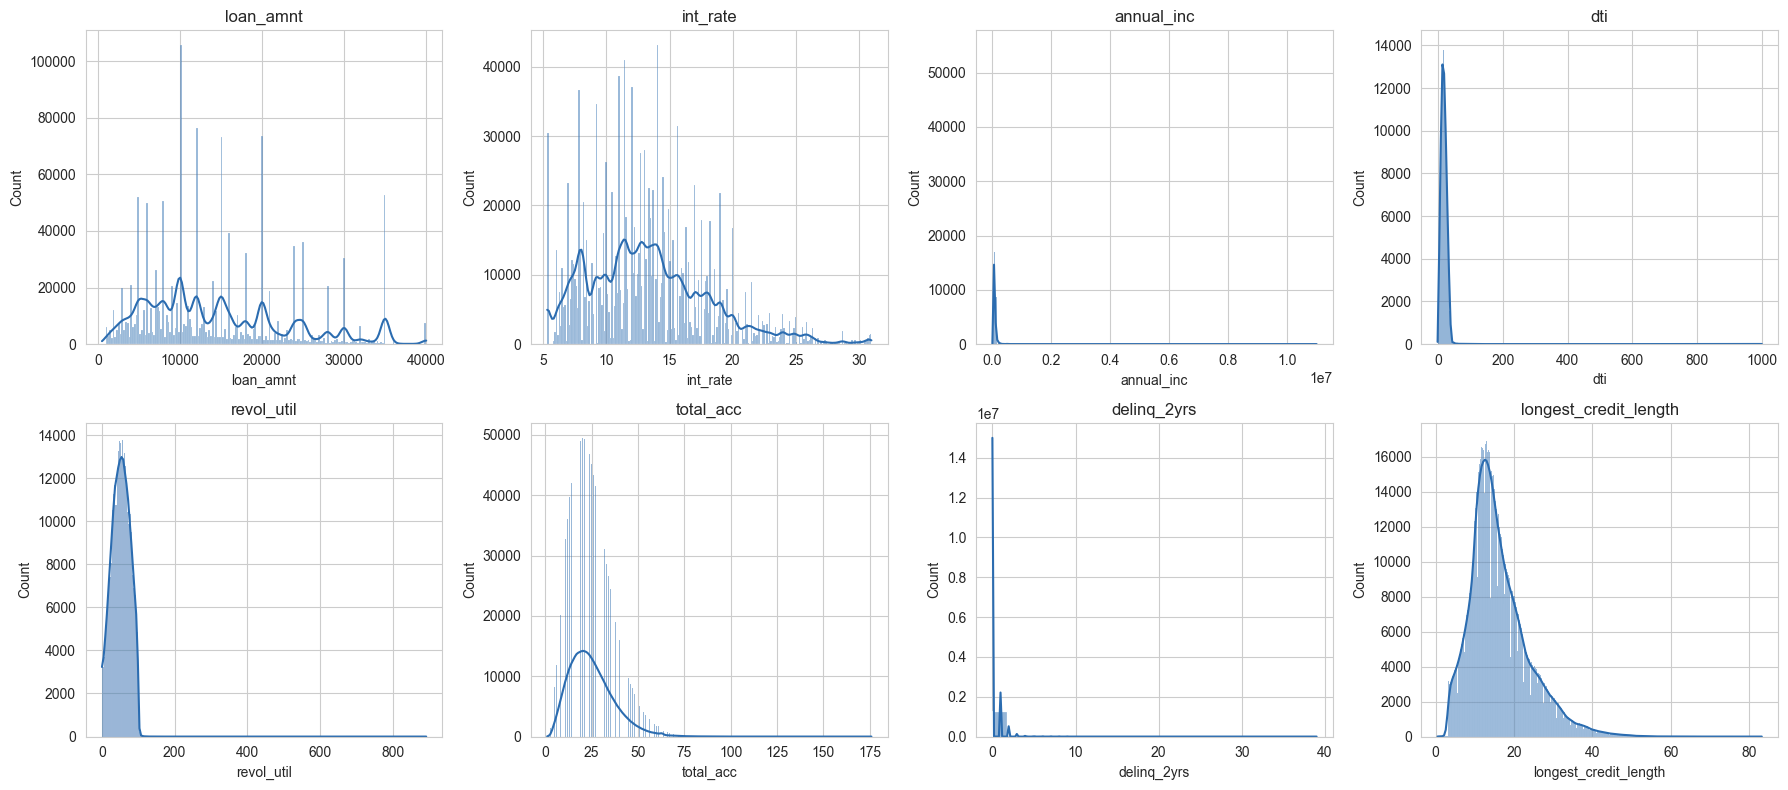

In [13]:
numeric_cols = ["loan_amnt", "int_rate", "annual_inc", "dti", "revol_util",
                "total_acc", "delinq_2yrs", "longest_credit_length"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(accepted_raw[col].dropna(), kde=True, ax=ax, color="#2b6cb0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 1.7 Correlation matrix against the target

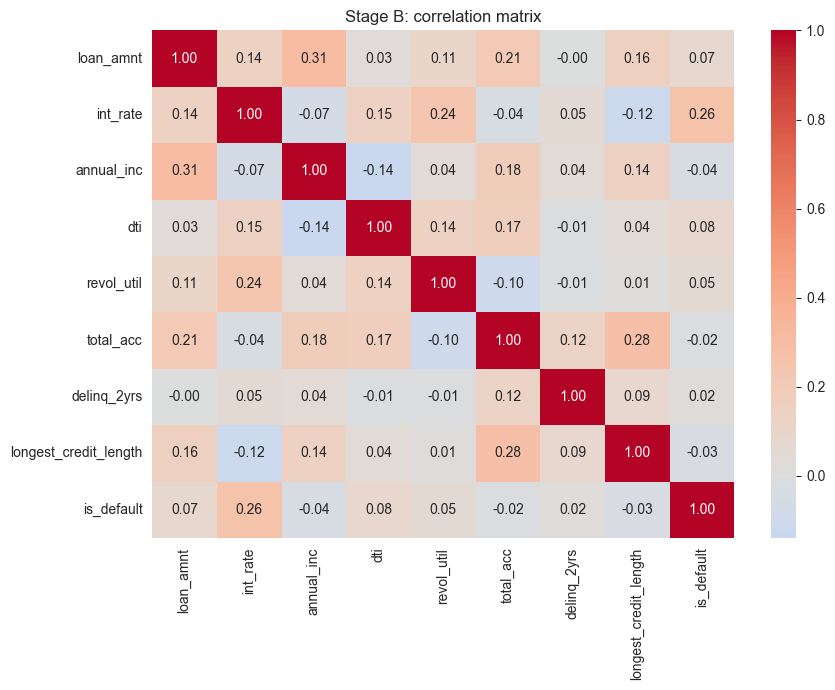


Top correlates with default:
is_default    1.000000
int_rate      0.263009
dti           0.084940
loan_amnt     0.071447
revol_util    0.054907
annual_inc    0.039598
Name: is_default, dtype: float64


In [15]:
corr = accepted_raw[numeric_cols + ["is_default"]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Stage B: correlation matrix")
plt.tight_layout()
plt.show()

print("\nTop correlates with default:")
print(corr["is_default"].abs().sort_values(ascending=False).head(6))

### 1.8 Boxplots — candidate outliers

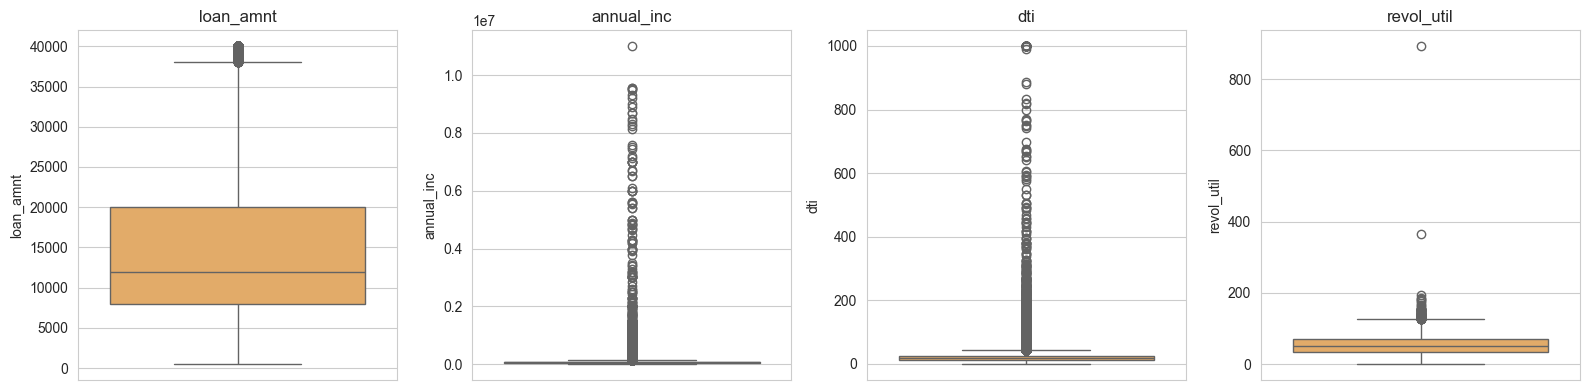

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["loan_amnt", "annual_inc", "dti", "revol_util"]):
    sns.boxplot(y=accepted_raw[col], ax=ax, color="#f6ad55")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 1.9 Cleaned + feature-engineered view


In [17]:
clean_df, clean_log = preprocessing.clean_accepted_data(accepted_raw)
fe_df = feature_engineering.engineer_stage_b_features(clean_df)

print("Cleaning log:")
for k, v in clean_log.items():
    print(f"  {k}: {v}")

fe_df[feature_engineering.STAGE_B_IDEAL_NUMERIC].describe().T

2026-09-13 14:21:28,632 [INFO] Excluding 21467 loans with a non-terminal loan_status (Current, Late, In Grace Period) -- outcome not yet known.
2026-09-13 14:22:11,228 [INFO] Stage B cleaning complete: 1348099 -> 1348099 rows, 99 columns


Cleaning log:
  columns_dropped_high_missingness_or_leakage: 54
  duplicates_removed: 0
  imputation_values: {'emp_length': 6.0, 'annual_inc': 65000.0, 'dti': 17.61, 'delinq_2yrs': 0.0, 'inq_last_6mths': 0.0, 'mths_since_last_delinq': 31.0, 'mths_since_last_record': 71.0, 'open_acc': 11.0, 'pub_rec': 0.0, 'revol_util': 52.2, 'total_acc': 23.0, 'collections_12_mths_ex_med': 0.0, 'mths_since_last_major_derog': 44.0, 'annual_inc_joint': 106291.0, 'dti_joint': 18.46, 'acc_now_delinq': 0.0, 'tot_coll_amt': 0.0, 'tot_cur_bal': 80231.0, 'open_acc_6m': 1.0, 'open_act_il': 2.0, 'open_il_12m': 1.0, 'open_il_24m': 1.0, 'mths_since_rcnt_il': 12.0, 'total_bal_il': 24061.5, 'il_util': 75.0, 'open_rv_12m': 1.0, 'open_rv_24m': 2.0, 'max_bal_bc': 4201.0, 'all_util': 59.0, 'total_rev_hi_lim': 24100.0, 'inq_fi': 1.0, 'total_cu_tl': 0.0, 'inq_last_12m': 2.0, 'acc_open_past_24mths': 4.0, 'avg_cur_bal': 7407.0, 'bc_open_to_buy': 4700.0, 'bc_util': 63.2, 'chargeoff_within_12_mths': 0.0, 'delinq_amnt': 0.0, '

,count,mean,std,min,25%,50%,75%,max
loan_amnt,1348099.0,14383.635382,8636.942978,1500.000000,7975.000000,12000.000000,20000.000000,3.500000e+04
int_rate,1348099.0,13.241562,4.765685,5.310000,9.750000,12.740000,15.990000,3.099000e+01
installment,1348099.0,437.777843,261.497190,4.930000,248.280000,375.040000,580.220000,1.719830e+03
emp_length,1348099.0,5.964265,3.582663,0.000000,3.000000,6.000000,10.000000,1.000000e+01
annual_inc,1348099.0,74612.421381,42166.129418,18000.000000,45750.000000,65000.000000,90000.000000,2.510000e+05
dti,1348099.0,18.127693,8.427804,1.770000,11.790000,17.610000,24.050000,3.846000e+01
delinq_2yrs,1348099.0,0.317626,0.877736,0.000000,0.000000,0.000000,0.000000,3.900000e+01
revol_util,1348099.0,51.796753,24.442665,1.100000,33.500000,52.200000,70.700000,9.820000e+01
revol_bal,1348099.0,16270.715447,22477.508148,0.000000,5936.000000,11130.000000,19758.000000,2.904836e+06
total_acc,1348099.0,24.975946,12.003434,1.000000,16.000000,23.000000,32.000000,1.760000e+02


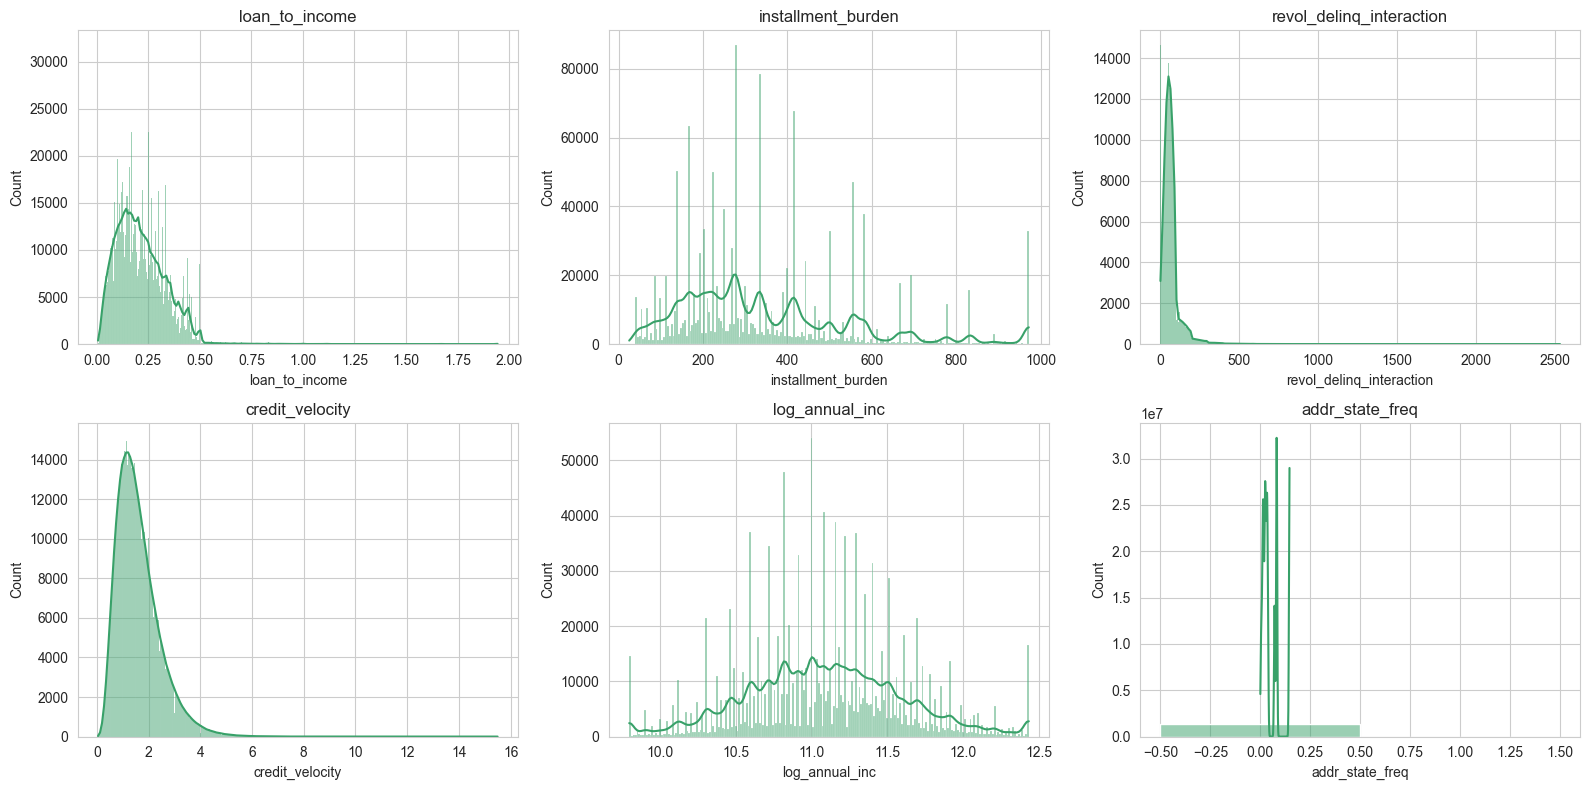

In [18]:
engineered = ["loan_to_income", "installment_burden", "revol_delinq_interaction",
              "credit_velocity", "log_annual_inc", "addr_state_freq"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), engineered):
    sns.histplot(fe_df[col], kde=True, ax=ax, color="#38a169")
    ax.set_title(col)
plt.tight_layout()
plt.show()

---
## Part 2 — Stage A: Accepted + Rejected Data (Acceptance Prediction)

In [19]:
try:
    rejected_raw = data_loader.load_rejected_data()
    stage_a_available = True
    print("Rejected data loaded:", rejected_raw.shape)
except FileNotFoundError as e:
    stage_a_available = False
    print("Stage A data not yet available:\n")
    print(e)

2026-09-13 14:23:57,776 [INFO] Loading local rejected-application data from C:\Users\user\Documents\Research\Actual MSc Thesis\Full Update September Project\LOAN_XAI\data\rejected_2007_to_2018Q4.csv


Rejected data loaded: (27648741, 9)


### 2.1 Shape and data types (rejected applications)

In [20]:
if stage_a_available:
    print("Shape:", rejected_raw.shape)
    display(rejected_raw.dtypes)
else:
    print("Skipped -- see message above.")

Shape: (27648741, 9)


Amount Requested        float64
Application Date         object
Loan Title               object
Risk_Score              float64
Debt-To-Income Ratio     object
Zip Code                 object
State                    object
Employment Length        object
Policy Code             float64
dtype: object

### 2.2 Summary statistics

In [21]:
if stage_a_available:
    display(rejected_raw.describe(include="all").T)
else:
    print("Skipped -- see message above.")

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Amount Requested,27648741.0,NaN,NaN,NaN,13133.240309,15009.636324,0.0,4800.0,10000.0,20000.0,1400000.0
Application Date,27648741,4238,2018-12-04,42112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Loan Title,27647436,73927,Debt consolidation,6418016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Risk_Score,9151111.0,NaN,NaN,NaN,628.17209,89.936793,0.0,591.0,637.0,675.0,990.0
Debt-To-Income Ratio,27648741,126145,100%,1362556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,27648448,1001,112xx,267102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,27648719,51,CA,3242169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employment Length,26697386,11,< 1 year,22994315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Policy Code,27647823.0,NaN,NaN,NaN,0.006375,0.112737,0.0,0.0,0.0,0.0,2.0


### 2.3 Combined acceptance target balance

2026-09-13 14:25:42,768 [INFO] Excluding 21467 loans with a non-terminal loan_status (Current, Late, In Grace Period) -- outcome not yet known.
2026-09-13 14:26:30,827 [INFO] Stage B cleaning complete: 1348099 -> 1348099 rows, 99 columns
2026-09-13 14:29:09,145 [INFO] Stage A cleaning complete: 27648741 -> 27489007 rows, 9 columns
2026-09-13 14:29:31,523 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-13 14:29:31,557 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Combined shape: (28837106, 7)
accepted
0    0.9533
1    0.0467
Name: proportion, dtype: float64


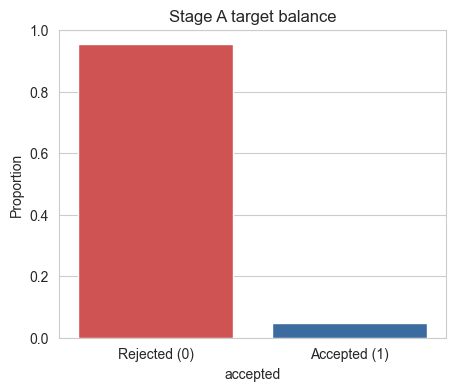

In [22]:
if stage_a_available:
    accepted_clean, _ = preprocessing.clean_accepted_data(accepted_raw)
    rejected_clean, rej_log = preprocessing.clean_rejected_data(rejected_raw)
    combined = feature_engineering.engineer_stage_a_features(accepted_clean, rejected_clean)

    print("Combined shape:", combined.shape)
    target_balance_a = combined["accepted"].value_counts(normalize=True).round(4)
    print(target_balance_a)

    plt.figure(figsize=(5, 4))
    sns.barplot(x=target_balance_a.index.astype(str), y=target_balance_a.values,
                palette=["#e53e3e", "#2b6cb0"])
    plt.xticks([0, 1], ["Rejected (0)", "Accepted (1)"])
    plt.ylabel("Proportion")
    plt.title("Stage A target balance")
    plt.show()
else:
    print("Skipped -- see message above.")

### 2.4 Distributions of the six shared fields

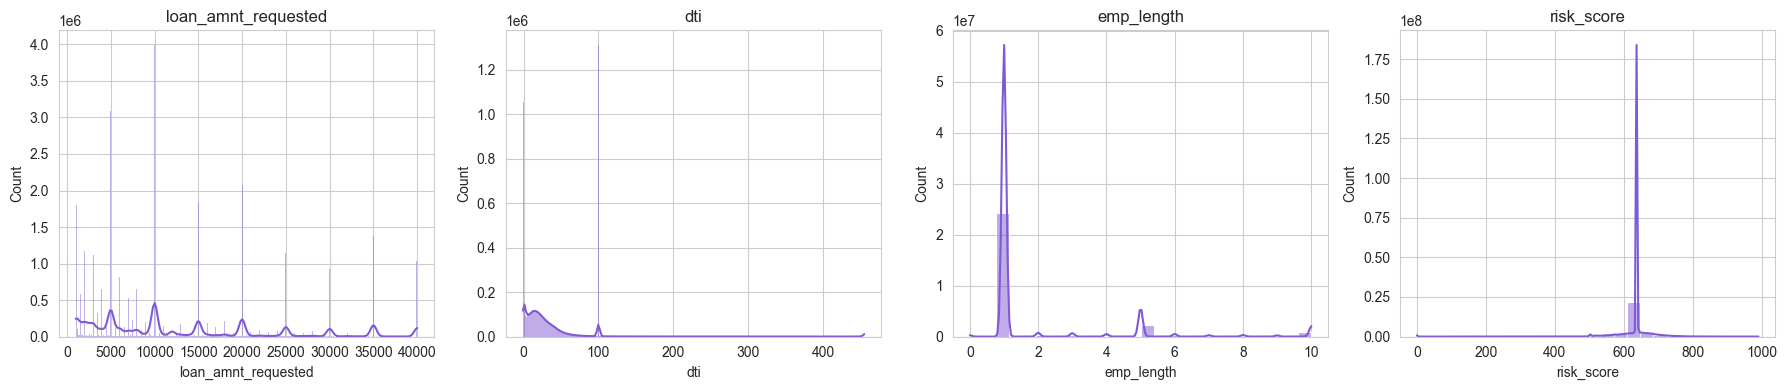

In [23]:
if stage_a_available:
    shared_numeric = ["loan_amnt_requested", "dti", "emp_length", "risk_score"]
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, col in zip(axes, shared_numeric):
        sns.histplot(combined[col].dropna(), kde=True, ax=ax, color="#805ad5")
        ax.set_title(col)
    plt.tight_layout()
    plt.show()
else:
    print("Skipped -- see message above.")

### 2.5 What to look for here

Per Jagtiani (2019), employment length dominated the funding decision on
this exact accepted+rejected LendingClub population (88% relative
importance), well ahead of loan amount (6%) and DTI (5%). Section 4's SHAP
analysis (Chapter Four) is the place to check whether this thesis's own
Stage A model reproduces that pattern or diverges from it — either result
is reportable, and a divergence is worth explaining rather than treating as
an error.

---
## Summary

Both EDA passes feed directly into `run_pipeline.py`'s cleaning and feature-engineering stages. Nothing computed in this notebook is recomputed differently by the pipeline script — they call the same functions in `src/preprocessing.py` and `src/feature_engineering.py`.